In [41]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import os, sys
from astropy.io import fits
import healpy as hp

import pandas as pd

from scipy import interpolate
from scipy import optimize
from scipy.stats import poisson
from scipy import signal

sys.path.append('..')

from tqdm import tqdm

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file('../notebooks/matplotlibrc')

## 1. Convert to cartesian

In [53]:
from utils.cart import to_cart
from utils import create_mask as cm

In [56]:
# Load standard templates and convert to Cartesian
extent = 20  # Semi-extent in degrees
n_pixels = 80  # Number of pixels
pixelsize = 2 * extent / n_pixels

for k in ['gce', 'psc', 'iso', 'dsk', 'bub', 'p6v11', 'ccwaics', 'ccwapibrem', 'ccwfics', 'ccwfpibrem']:
    temp = to_cart(np.load(f"data/healpix/template_{k}_512.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
    np.save(f"data/cart/template_{k}.npy", temp)
    print(k, end=' ')
print()
for k in ['exposure', 'counts']:
    temp = to_cart(np.load(f"data/fermidata_{k}_512.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
    np.save(f"data/cart/fermidata_{k}.npy", temp)
    print(k, end=' ')

gce psc iso dsk bub p6v11 ccwaics ccwapibrem ccwfics ccwfpibrem 
exposure counts 

## 2. Manually gtscrmap

### 2.1 KingPSF

In [19]:
from models.psf import KingPSF

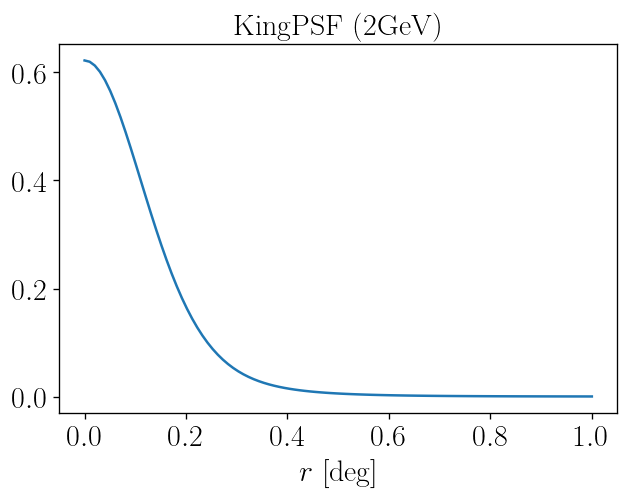

In [31]:
psf = KingPSF()
x = np.linspace(0, 1, 100) # [deg]
plt.plot(x, psf.psf_fermi_r(np.deg2rad(x)))
plt.title('KingPSF (2GeV)')
plt.xlabel(r'$r$ [deg]');

### 2.2 gtsrcmap

In [42]:
# target config
extent_pad = 25 # [deg] | Semi-extent | pad stands for padded
pixelsize_pad = 0.5 # [deg]
n_pixels_pad = int(2 * extent_pad / pixelsize_pad)
pixel_centers_pad = np.linspace(-extent_pad, extent_pad, n_pixels_pad, endpoint=False) + pixelsize_pad / 2

extent = 20 # Semi-extent in degrees
pixelsize = 0.5 # [deg]
n_pixels = int(2 * extent / pixelsize)

In [48]:
tag = 'ccwapibrem'
hdu = fits.open(f"data/ccw_templates/{tag}.fit")

e_temp = hdu[1].data['ENERGY']
n_e = len(e_temp)

if 'ccwa' in tag: # map is in 1 degree
    
    extent_lr = 25  # [deg] | Semi-extent | lr stands for low resolution
    pixelsize_lr = 1 # [deg]
    n_pixels_lr = int(2 * extent_lr / pixelsize_lr)
    pixel_centers_lr = np.linspace(-extent_lr, extent_lr, n_pixels_lr, endpoint=False) + pixelsize_lr / 2
    
    temp_pad_arr = np.zeros((n_e, n_pixels_pad, n_pixels_pad))
    
    for i_e in tqdm(range(n_e)):
        
        ## 1. piece together low res map
        temp_lr = np.zeros((n_pixels_lr, n_pixels_lr)) # -25 deg to 25 deg
        r = int(extent_lr / pixelsize_lr) # half extent pixel count
        b_c = 90 # index of pixel to the 'right' of the center edge (b=0) | 90 because of 90 degrees / 1 degree
        for l_i in range(r): # right half
            temp_lr[:, r+l_i] = hdu[0].data[i_e, b_c-r:b_c+r, l_i] # right half
        for l_i in range(r): # left half
            temp_lr[:, l_i] = hdu[0].data[i_e, b_c-r:b_c+r, -r+l_i] # left half
            
        ## 2. upsample (to padded)
        temp_lr_interp = interpolate.interp2d(pixel_centers_lr, pixel_centers_lr, temp_lr)
        temp_pad_arr[i_e] = temp_lr_interp(pixel_centers_pad, pixel_centers_pad)
        
    ## 3. multiple with exposure
    temp_pad_e_interp = interpolate.interp1d(e_temp, temp_pad_arr, axis=0)
        
        ## 3. Convolve with KingPSF

100%|██████████| 38/38 [00:00<00:00, 1815.16it/s]


In [61]:
hdu = fits.open('data/exposure-ultracleanveto-bestpsf.fits')

In [91]:
e = np.logspace(np.log10(2e2), np.log10(2e6), 41)
t = (e[:-1] + e[1:]) / 2
s = np.sqrt(e[:-1] * e[1:])

In [94]:
s

array([2.24403691e+02, 2.82507509e+02, 3.55655882e+02, 4.47744228e+02,
       5.63676586e+02, 7.09626778e+02, 8.93367184e+02, 1.12468265e+03,
       1.41589157e+03, 1.78250188e+03, 2.24403691e+03, 2.82507509e+03,
       3.55655882e+03, 4.47744228e+03, 5.63676586e+03, 7.09626778e+03,
       8.93367184e+03, 1.12468265e+04, 1.41589157e+04, 1.78250188e+04,
       2.24403691e+04, 2.82507509e+04, 3.55655882e+04, 4.47744228e+04,
       5.63676586e+04, 7.09626778e+04, 8.93367184e+04, 1.12468265e+05,
       1.41589157e+05, 1.78250188e+05, 2.24403691e+05, 2.82507509e+05,
       3.55655882e+05, 4.47744228e+05, 5.63676586e+05, 7.09626778e+05,
       8.93367184e+05, 1.12468265e+06, 1.41589157e+06, 1.78250188e+06])

In [95]:
hdu[1].data['ENERGY']

array([2.24403691e+02, 2.82507509e+02, 3.55655882e+02, 4.47744228e+02,
       5.63676586e+02, 7.09626778e+02, 8.93367184e+02, 1.12468265e+03,
       1.41589157e+03, 1.78250188e+03, 2.24403691e+03, 2.82507509e+03,
       3.55655882e+03, 4.47744228e+03, 5.63676586e+03, 7.09626778e+03,
       8.93367184e+03, 1.12468265e+04, 1.41589157e+04, 1.78250188e+04,
       2.24403691e+04, 2.82507509e+04, 3.55655882e+04, 4.47744228e+04,
       5.63676586e+04, 7.09626778e+04, 8.93367184e+04, 1.12468265e+05,
       1.41589157e+05, 1.78250188e+05, 2.24403691e+05, 2.82507509e+05,
       3.55655882e+05, 4.47744228e+05, 5.63676586e+05, 7.09626778e+05,
       8.93367184e+05, 1.12468265e+06, 1.41589157e+06, 1.78250188e+06])

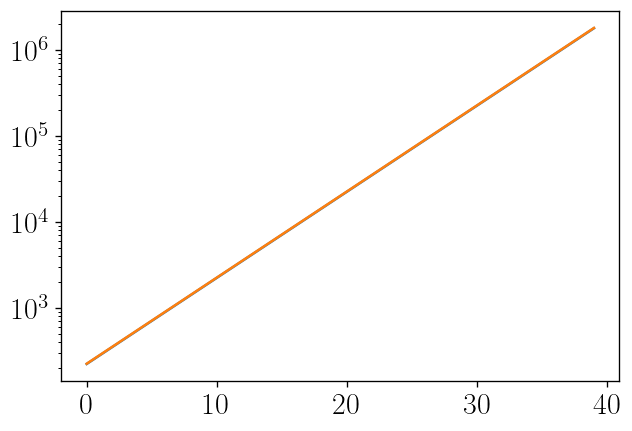

In [88]:
plt.plot(hdu[1].data['ENERGY'])
plt.plot(t)
plt.yscale('log')

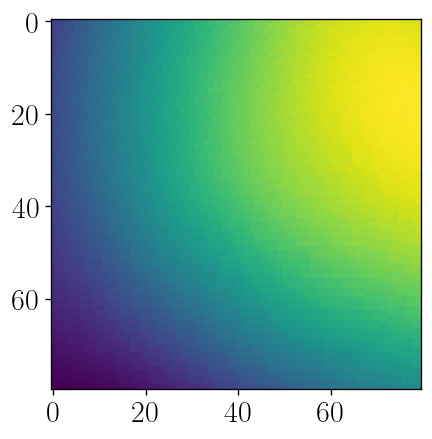

In [58]:
plt.imshow(z)

In [35]:
np.searchsorted(hdu[1].data['ENERGY'], 2e3)

15

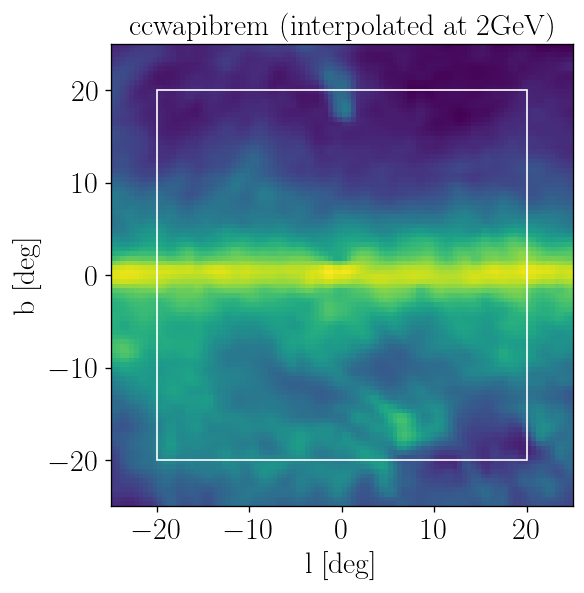

In [52]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(np.log(np.fliplr(temp_pad_e_interp(2e3))), extent=(-extent_lr, extent_lr, -extent_lr, extent_lr))
ax.add_patch(mpl.patches.Rectangle((-20,-20), 40, 40, fc=(0,0,0,0), ec='w'))
ax.set(title='ccwapibrem (interpolated at 2GeV)', xlabel='l [deg]', ylabel='b [deg]');

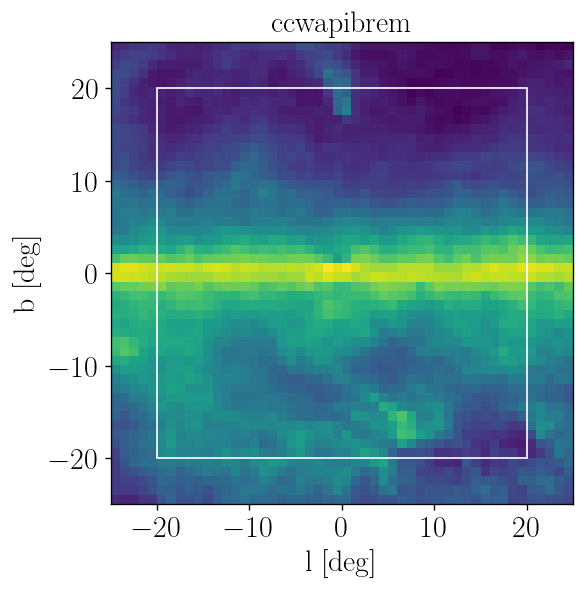

In [37]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(np.log(np.fliplr(temp_lr)), extent=(-extent_lr, extent_lr, -extent_lr, extent_lr))
ax.add_patch(mpl.patches.Rectangle((-20,-20), 40, 40, fc=(0,0,0,0), ec='w'))
ax.set(title='ccwapibrem', xlabel='l [deg]', ylabel='b [deg]');

In [46]:
counts = np.load('data/counts_573week.npy')

In [ ]:
# Load original CCW maps

In [ ]:
# Compare to gtsrcmap output

In [ ]:
# Smooth

In [ ]:
# Compare distance again